In [1]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [3]:
ds <- read.csv("BCO-DMO/zooplankton.csv", na.strings=c("nd","?"))

In [4]:
names(ds)

[1] "Cruise"            "Cruise_ID"         "Day"              
 [4] "Month"             "Year"              "Date"             
 [7] "Latitude"          "Longitude"         "Analyst"          
[10] "Mesh_Size"         "TOTAL_DENSITY"     "BIOMASS"          
[13] "ASH"               "COPEPODS"          "CALANOIDS"        
[16] "CYCLOPOIDA"        "HAPARCTICOIDA"     "POECILOSTOMATOIDA"
[19] "L_FISH"            "H_FISH"            "CHAETOGNATHA"     
[22] "CLADOCEROS"        "OSTRACODA"         "FORAMINIFERA"     
[25] "AMPHIPODS"         "ISOPODS"           "EUPHAUSIIDS"      
[28] "MISYDACEA"         "SERGESTID"         "L_CRUSTACEA"      
[31] "N_COPEPOD"         "C_COPEPOD"         "N_CIRRIPEDIA"     
[34] "C_CIRRIPEDIA"      "L_DECAPODA"        "L_STOMATOPODA"    
[37] "L_EUPHAUSIID"      "L_SERGESTID"       "POLICHAETES"      
[40] "L_CYPHONAUTES"     "MEDUSA"            "SIPHONOPHORES"    
[43] "CTENOPHORES"       "L_ECHINODERMS"     "PTEROPODS"        
[46] "HETEROPODS"        "GASTROPODS"        "L_CEPHALOPODA"    
[49] "L_BIVALVE"         "L_GASTROPOD"       "PROTOZOAN"        
[52] "RADIOLARIAN"       "APPENDICULARIANS"  "SALPS"            
[55] "DOLIOLIDS"         "BIVALVES"          "H_CRUSTACEA"      
[58] "L_ANFIOXUS"        "LUCIFER"           "JUV_GASTROPOD"

In [6]:
str(ds)

'data.frame':	306 obs. of  60 variables:
 $ Cruise           : int  71 71 72 72 73 73 74 74 75 75 ...
 $ Cruise_ID        : chr  "CAR-071" "CAR-071" "CAR-072" "CAR-072" ...
 $ Day              : int  9 9 6 6 11 11 10 10 14 14 ...
 $ Month            : int  10 10 11 11 12 12 1 1 2 2 ...
 $ Year             : int  2001 2001 2001 2001 2001 2001 2002 2002 2002 2002 ...
 $ Date             : chr  "2001-10-09" "2001-10-09" "2001-11-06" "2001-11-06" ...
 $ Latitude         : num  10.5 10.5 10.5 10.5 10.5 ...
 $ Longitude        : num  -64.7 -64.7 -64.7 -64.7 -64.7 ...
 $ Analyst          : chr  "Javier Gutierrez" "Javier Gutierrez" "Javier Gutierrez" "Javier Gutierrez" ...
 $ Mesh_Size        : int  200 500 500 200 200 500 200 500 200 500 ...
 $ TOTAL_DENSITY    : num  1112.6 212.9 13.4 282.3 572.6 ...
 $ BIOMASS          : num  26.83 15.95 2.34 7.43 5.6 ...
 $ ASH              : num  6.8428 3.3093 0.0724 0.6393 0.1423 ...
 $ COPEPODS         : num  741.76 160.22 5.62 197.28 440.18 ...
 $ CAL

# A tibble: 47 × 2
   Taxon             Mean_Abundance
   <chr>                      <dbl>
 1 COPEPODS                  272.  
 2 CALANOIDS                 174.  
 3 CYCLOPOIDA                 96.0 
 4 C_COPEPOD                  74.1 
 5 L_CRUSTACEA                60.2 
 6 POECILOSTOMATOIDA          17.7 
 7 FORAMINIFERA               11.9 
 8 N_COPEPOD                  11.1 
 9 CHAETOGNATHA                6.61
10 CLADOCEROS                  5.87
11 OSTRACODA                   5.67
12 APPENDICULARIANS            5.60
13 PROTOZOAN                   2.95
14 PTEROPODS                   2.39
15 HAPARCTICOIDA               2.34
16 AMPHIPODS                   2.00
17 L_DECAPODA                  1.93
18 H_FISH                      1.88
19 C_CIRRIPEDIA                1.67
20 SALPS                       1.59
# ℹ 27 more rows


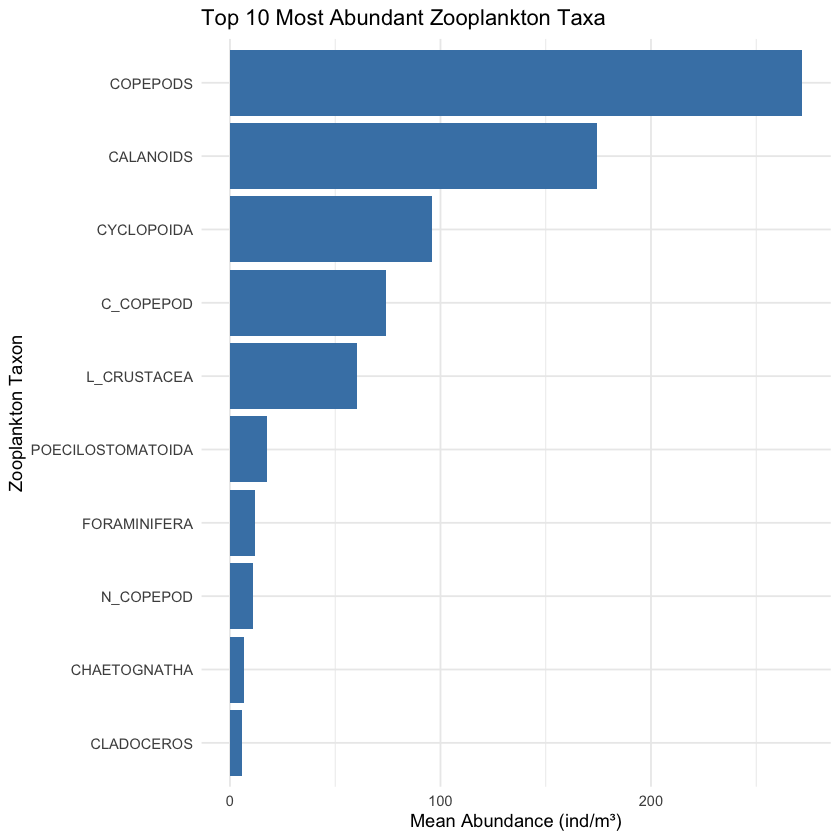

In [7]:
# Select only the zooplankton abundance columns (excluding metadata and totals)
abundance_cols <- ds %>%
  select(COPEPODS:JUV_GASTROPOD, -TOTAL_DENSITY, -BIOMASS, -ASH) %>%
  colnames()

# Calculate mean abundance for each taxon across all samples
mean_abundance <- ds %>%
  summarise(across(all_of(abundance_cols), ~mean(.x, na.rm = TRUE))) %>%
  pivot_longer(everything(), names_to = "Taxon", values_to = "Mean_Abundance") %>%
  arrange(desc(Mean_Abundance))

# View the results
print(mean_abundance, n = 20)

# Quick visualization of top 10
mean_abundance %>%
  slice_head(n = 10) %>%
  ggplot(aes(x = reorder(Taxon, Mean_Abundance), y = Mean_Abundance)) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  labs(x = "Zooplankton Taxon", 
       y = "Mean Abundance (ind/m³)",
       title = "Top 10 Most Abundant Zooplankton Taxa") +
  theme_minimal()

In [4]:
head(ds$Date)

[1] "2001-10-09" "2001-10-09" "2001-11-06" "2001-11-06" "2001-12-11"
[6] "2001-12-11"

In [5]:
ds$date <- as.Date(as.character(ds$Date), format="%Y-%m-%d")

In [6]:
# BIOMASS - Dry Weight - miligrams per meter cubed (mg/m3) 

In [7]:
test_zoo <- ds %>%
    select(BIOMASS, Mesh_Size, date) %>%
    pivot_wider(names_from=Mesh_Size, values_from=BIOMASS) %>%
    rename("Mesh200" = "200",
          "Mesh500" = "500")

In [8]:
saveRDS(test_zoo, "processed/Zoo_dryBiomass.rds")